# 1. Import the required libraries

In [1]:
# Standard code libraries

import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Custom code libraries from ReSurfEMG
import resurfemg
from resurfemg.data_connector.config import ConfigCreatorWidget
from resurfemg.data_connector.data_classes import EmgDataGroup, VentilatorDataGroup
from resurfemg.data_connector.tmsisdk_lite import Poly5Reader

%matplotlib widget

## 2. Load the ventilator and sEMG data

In [2]:
creator = ConfigCreatorWidget("config_IC.json")

INFO:resurfemg.data_connector.config:Loaded config from: config_IC.json
INFO:resurfemg.data_connector.config:Loaded config from: config.json


In [3]:
# Identify all recordings available for the selected patient/measurement_date

# Root directory for test data
config = creator.get_config()
root_patient_data_directory = config.get_directory("patient_data")

emg_and_vent_files = [str(file) for file in Path(root_patient_data_directory).rglob("**/*.Poly5")]
emg_files = []
vent_files = []

for file in emg_and_vent_files:
    if "vent" in file or "Draeger" in file:
        vent_files.append(file)
    else:
        emg_files.append(file)

emg_file_chosen = emg_files[0]
vent_file_chosen = vent_files[0]
print("The chosen files are:\n", emg_file_chosen, "\n", vent_file_chosen)

The chosen files are:
 \\ad.utwente.nl\Org\TNW\CRPH\Projects\2021_Warnaar_TOPSPIN_studie\4_Patient_data\1_RAW\MST017\2022-12-09_12-39-29\001\EMG_recording.Poly5 
 \\ad.utwente.nl\Org\TNW\CRPH\Projects\2021_Warnaar_TOPSPIN_studie\4_Patient_data\1_RAW\MST017\2022-12-09_12-39-29\001\Draeger_recording.Poly5


In [49]:
# Load the EMG and ventilator data recordings from the selected folders.
data_emg = Poly5Reader(emg_file_chosen)
data_vent = Poly5Reader(vent_file_chosen)
data_emg_samples = data_emg.samples[: data_emg.num_samples]
fs_emg = data_emg.sample_rate
data_vent_samples = data_vent.samples[: data_vent.num_samples]
fs_vent = data_vent.sample_rate

# Define the time series of the EMG and ventilator recordings
y_emg = data_emg_samples
y_vent = data_vent_samples

# Define the time axes
t_emg = [i / fs_emg for i in range(len(y_emg[0, :]))]
t_vent = [i / fs_vent for i in range(len(y_vent[0, :]))]

INFO:resurfemg.data_connector.tmsisdk_lite:Reading file \\ad.utwente.nl\Org\TNW\CRPH\Projects\2021_Warnaar_TOPSPIN_studie\4_Patient_data\1_RAW\MST017\2022-12-09_12-39-29\001\EMG_recording.Poly5


INFO:resurfemg.data_connector.tmsisdk_lite:	 Number of samples:  699136 
INFO:resurfemg.data_connector.tmsisdk_lite:	 Number of channels:  3 
INFO:resurfemg.data_connector.tmsisdk_lite:	 Sample rate: 2048 Hz
INFO:resurfemg.data_connector.tmsisdk_lite:Done reading data.
INFO:resurfemg.data_connector.tmsisdk_lite:Reading file \\ad.utwente.nl\Org\TNW\CRPH\Projects\2021_Warnaar_TOPSPIN_studie\4_Patient_data\1_RAW\MST017\2022-12-09_12-39-29\001\Draeger_recording.Poly5
INFO:resurfemg.data_connector.tmsisdk_lite:	 Number of samples:  34126 
INFO:resurfemg.data_connector.tmsisdk_lite:	 Number of channels:  3 
INFO:resurfemg.data_connector.tmsisdk_lite:	 Sample rate: 100 Hz
INFO:resurfemg.data_connector.tmsisdk_lite:Done reading data.


In [50]:
# Store the EMG data in a group of TimeSeries objects
n_channels_emg = y_emg.shape[0]

emg_timeseries = EmgDataGroup(y_emg, fs=fs_emg, labels=["ECG", "EMGdi", "EMGin"][:n_channels_emg],
                              units=n_channels_emg*["uV"])

# Data is stored in:
# fs        --> emg_timeseries.fs
# labels    --> emg_timeseries.labels
# units     --> emg_timeseries.units
# ECG       --> emg_timeseries.channels[0] = TimeSeries object
# EMGdi     --> emg_timeseries.channels[1] = TimeSeries object
# EMGin     --> emg_timeseries.channels[2] = TimeSeries object
#   with:
#   emg_timeseries.channels[0].fs = fs
#   emg_timeseries.channels[0].y_raw = y_emg[0, :]
#   emg_timeseries.channels[0].t_data = time axis data for y_raw
#   emg_timeseries.channels[0].y_clean = None
#   emg_timeseries.channels[0].y_baseline = None
#   emg_timeseries.channels[0].y_baseline = None
#   etc.
# From the labels 'ECG' is automatically detected.

In [51]:
# Store the ventilator data in a group of TimeSeries objects
n_channels_vent = y_vent.shape[0]
vent_timeseries = VentilatorDataGroup(y_vent, fs=fs_vent, labels=["Paw", "F", "Vvent"][:n_channels_vent],
                                      units=["cmH2O", "L/s", "L"][:n_channels_vent])

# Data is stored in:
# fs        --> vent_timeseries.fs
# labels    --> vent_timeseries.labels
# units     --> vent_timeseries.units
# ECG       --> vent_timeseries.channels[0: TimeSeries object
# EMGdi     --> vent_timeseries.channels[1] = TimeSeries object
#   with:
#   vent_timeseries.channels[0].fs = fs
#   vent_timeseries.channels[0].y_raw = y_vent[0, :]
#   vent_timeseries.channels[0].t_data = time axis data for y_raw
#   vent_timeseries.channels[0].y_clean = None
#   vent_timeseries.channels[0].y_baseline = None
#   vent_timeseries.channels[0].y_baseline = None
#   etc.
# From the labels 'P_aw', 'F', and 'Vvent' are automatically detected.

# 3. Pre-process the data

In [52]:
# Filter
emg_timeseries.filter()
# Which equals:
# emg_timeseries.filter(
#     signal_type='raw',
#     hp_cf=20.0,
#     lp_cf=500.0,
#     channel_idxs=[0, 1],
# )
# Where:
# signal_type:      Filter the raw, just assigned, data
# hp_cf:            High-pass cut-off frequency of 20 Hz
# lp_cf:            Low-pass cut-off frequency of 500 Hz
# channel_idxs:     For all channels (None would default to this)

# --> Data is stored in:
# emg_timeseries.channels[channel_idx].y_clean


In [53]:
# Gate the EMG
emg_timeseries.get_ecg_peaks()
emg_timeseries.gating()
# Which equals:
# emg_timeseries.gating(
#     signal_type='clean',
#     gate_width_samples=None,
#     ecg_peak_idxs=None,
#     ecg_raw=None,
#     bp_filter=True,
#     channel_idxs=None,
# )
# Where:
# signal_type:          Filter the clean, just filtered, data
# gate_width_samples:   Gate width, `None` defaults to fs // 10
# ecg_peak_idxs:        Sample idxs of ECG peaks, when `None` peaks are
#                       automatically identified.
# ecg_raw:              ECG data to detect ECG peaks in if no ecg_peak_idxs are
#                       provided. If `None` and no ecg-channel is detected
#                       from the labels the raw channel data is used.
# bp_filter:            True/False: Filter the provided ecg_raw between 1-500
#                       Hz before peak detection
# channel_idxs:         For all channels (None would default to this)

# --> Data is stored in:
# emg_timeseries.channels[channel_idx].y_clean


In [54]:
# Calculate the envelope of the signal
emg_timeseries.envelope()
# Which equals:
# emg_timeseries.envelope(
#     env_window=None,
#     env_type='rms',
#     signal_type='clean',
# )
# Where:
# env_window:           Envelope window width, `None` defaults to fs // 5
# env_type:             'rms' for root-mean-square (default), 'arv' for average
#                       rectified
# signal_type:          Calculate the envelope over the clean data

# --> Data is stored in:
# emg_timeseries.channels[channel_idx].y_env

In [55]:
# Calculate the baseline for the EMG envelopes and p_vent
emg_timeseries.baseline()
# Which equals:
# emg_timeseries.baseline(
#     percentile=33,
#     window_s=int(7.5 * fs_emg),
#     step_s=fs_emg // 5,
#     method='default',
#     signal_type='env',
#     augm_percentile=25,
#     ma_window=None,
#     perc_window=None,
#     channel_idxs=[0, 1],
# )
# Where:
# percentile:       Percentile of signal in the window to take as the baseline
#                   value
# window_s:         Window length in samples (default: int(7.5 * fs))
# step_s:           Number of consecutive samples with the same baseline value
#                   (default: fs // 5)
# method:           'default' or 'slopesum'
# signal_type:      Calculate the baseline over the envelope (y_env) for emg
#                   and over the original signal for p_vent
# augm_percentile   Augmented_percentile for slopesum baseline
# ma_window:        Moving average window in samples for average dy/dt in
#                   slopesum baseline
# perc_window:      'perc_window' for slopesum baseline.
# channel_idxs:     For all channels (None would default to this)

# --> Data is stored in:
# emg_timeseries.channels[channel_idx].y_baseline

vent_timeseries.baseline(channel_idxs=[0], signal_type="raw")

c:\Users\ManinettiC\Documents\ReSurfEMG\resurfemg\data_connector\data_classes.py:674: FutureWarning: The "signal_type" argument is deprecated. Use "signal_io"
instead: signal_io = (`input_name`, `output_name`).
  warnings.warn(


In [56]:
#get the range of the t_emg
t_emg_range = [np.amin(t_emg), np.max(t_emg)]
t_emg_range

[np.float64(0.0), np.float64(341.37451171875)]

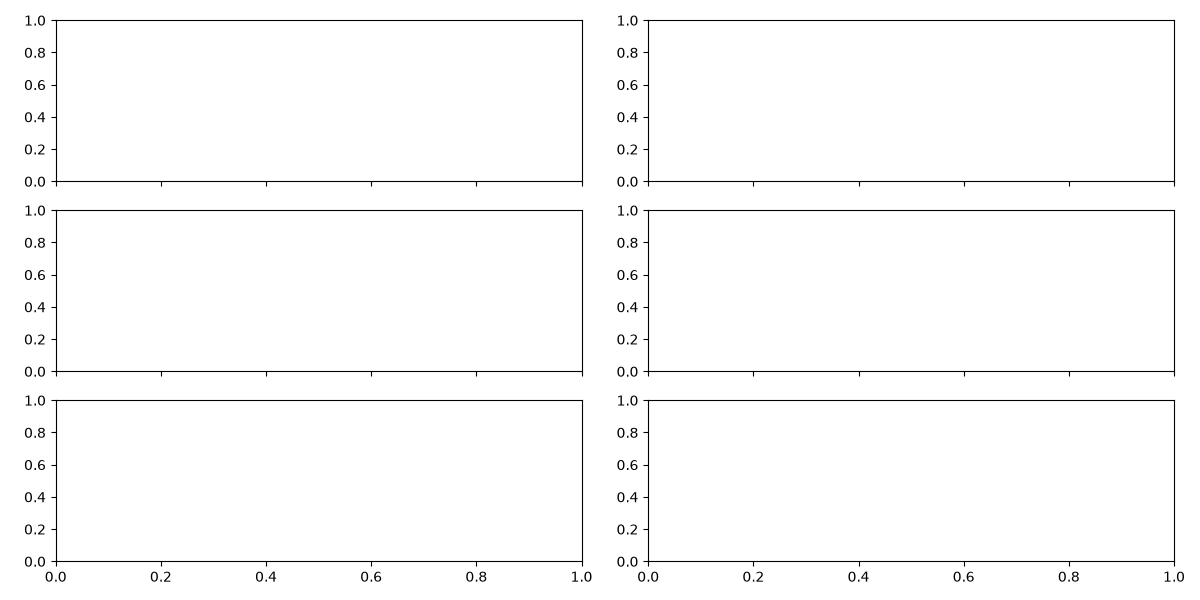

c:\Users\ManinettiC\Documents\ReSurfEMG\resurfemg\data_connector\data_classes.py:1027: FutureWarning: The "signal_type" argument is deprecated. Use "signal_io"
instead: signal_io = (`input_name`,).
  warnings.warn(


(0.0, 341.37451171875)

In [57]:
# Plot the raw data with the envelope
# EMG data
plt.close("all")

importlib.reload(resurfemg.data_connector.data_classes)
fig, axis = plt.subplots(nrows=max(n_channels_emg, n_channels_vent),
                         ncols=2, figsize=(12, 6), sharex=True, layout="tight")
plt.show()
axes_emg = axis[:, 0]
axes_vent = axis[:, 1]

colors = ["tab:cyan", "tab:orange", "tab:green"]
emg_timeseries.plot_full(axes=axes_emg, signal_type="clean", baseline_bool=False)
emg_timeseries.plot_full(axes=axes_emg, signal_type="env", colors=colors)
if n_channels_emg < axis.shape[0]:
    for i in range(n_channels_emg, axis.shape[0]):
        axes_emg[i].axis("off")

# Which equals:
# emg_timeseries.plot_full(
#     axes=axes_emg,
#     channel_idxs=[0, 1],
#     signal_type='clean',
#     colors=['tab:cyan', 'tab:orange'],
#     baseline_bool=False
# )
# Where:
# axes:             Matplotlib axes object
# channel_idxs:     For all channels (None would default to this)
# signal_type:      Plot clean emg
# colors:           Plot the signal, and baseline in the respective colors
# baseline_bool:    Plot the baseline

# emg_timeseries.plot_full(axes=axes_emg, signal_type="env", colors=colors)

axes_emg[0].set_title("EMG data")
axes_emg[n_channels_emg - 1].set_xlabel("t (s)")

# Ventilator data data
vent_timeseries.plot_full(axes=axes_vent)

if n_channels_vent < axis.shape[0]:
    for i in range(n_channels_vent, axis.shape[0]):
        axes_vent[i].axis("off")

axes_vent[0].set_title("Ventilator data")
axes_vent[n_channels_vent - 1].set_xlabel("t (s)")
axes_vent[n_channels_vent - 1].set_xlim(t_emg_range)

# 3. Identify Pocc peaks of interest in p_vent

In [58]:
start_t = 0

In [59]:
# Find occlusion pressures
vent_timeseries.find_peep(vent_timeseries.p_vent_idx, vent_timeseries.v_vent_idx)
vent_timeseries.find_occluded_breaths(start_idx=start_t * vent_timeseries.fs)
# vent_timeseries.find_occluded_breaths(vent_timeseries.p_vent_idx, start_idx=start_t * vent_timeseries.fs)
# Which equals:
# vent_timeseries.find_occluded_breaths(
#     pressure_idx=vent_timeseries.p_vent_idx,
#     peep=vent_timeseries.peep,
#     start_idx=start_t*vent_timeseries.fs,
#     end_idx=len(y_vent)-1,
#     prominence_factor=0.8,
#     min_width_s=vent_timeseries.fs//10,
#     distance_s=vent_timeseries.fs//2,
# )
# Where:
# pressure_idx:         Channel idx of ventilator pressure signal (auto-detected)
# peep:                 Ventilator PEEP level (auto-detected)
# start_idx             Look for Pocc from sample idx
# end_idx:              Look for Pocc up to sample idx
# prominence_factor     Factor setting minimum prominence of Pocc peak
# min_width_s:          Mnimum Pocc peak width in samples
# distance_s:           Mnimum Pocc peak distance in samples

# --> Peak data is stored in:
# vent_timeseries.channels[vent_timeseries.p_vent_idx].peaks['Pocc']

In [60]:
# Detect on- and offsets of occlusion pressure peaks
p_vent = vent_timeseries[vent_timeseries.p_vent_idx]
p_vent.peaks["Pocc"].detect_on_offset(baseline=p_vent.y_baseline)
# Which equals:
# p_vent.peaks['Pocc'].detect_on_offset(
#     baseline=p_vent.y_baseline,
#     method='default',   # == 'baseline_crossing'
#     fs=p_vent.fs,
#     slope_window_s=p_vent.fs // 5
# )
# Where:
# baseline:         Baseline for on-/offset detection.
# method:           On-/Offset detection method, 'default' == 'baseline_crossing'
# fs:               Signal fs
# slope_window_s:   For method 'slope_extrapolation', the window in samples
#                   where the slope is maximal

# The timings of the peaks is at:
print("The timings of the Pocc peaks is at:")
print(p_vent.peaks["Pocc"].peak_df["peak_idx"] / p_vent.fs)

c:\Users\ManinettiC\Documents\ReSurfEMG\resurfemg\data_connector\data_classes.py:137: FutureWarning:  The attribute y_baseline is deprecated to allow for more, and custom,
signal types. Use "TimeSeries"[baseline] instead.
  warnings.warn(


The timings of the Pocc peaks is at:
0    100.7
Name: peak_idx, dtype: float64


c:\Users\ManinettiC\Documents\ReSurfEMG\resurfemg\data_connector\data_classes.py:162: FutureWarning:  The attribute fs is deprecated to allow for more parameters. Use
self.param["fs"] instead.
  warnings.warn(


In [61]:
# Find supported breath pressures
v_vent = vent_timeseries[vent_timeseries.v_vent_idx]
vent_timeseries.find_ventilator_peaks()
# Which equals:
# vent_timeseries.detect_ventilator_breath(
#     volume_idx=2,
#     start_idx=0,
#     end_idx=len(y_vent)-1,
#     width_s=v_vent.fs // 4,
#     threshold=0.25 * np.percentile(v_vent.y_raw, 90),
#     prominence=0.10 * np.percentile(v_vent.y_raw, 90),
#     threshold_new=0.5 * np.percentile(v_vent.y_raw[temp_peak_idxs], 90),
#     prominence_new=0.5 * np.percentile(v_vent.y_raw, 90),
#     pressure_idx=0,
# )
# Where:
# volume_idx:           Channel idx of ventilator volume signal (auto-detected)
# start_idx             Look for supported ventilator breath from sample idx
# end_idx:              Look for supported ventilator breath up to sample idx
# width_s:              Minimum supported ventilator breath width in samples
# threshold:            Minimum supported ventilator breath height in samples
# prominence:           Minimum supported ventilator breath prominence in samples
# threshold_new:        threshold, but filtering true breaths from originally identified peaks
# prominence_new:       prominence, but filtering true breaths from originally identified peaks
# pressure_idx:         Channel idx of ventilator pressure signal (auto-detected)

# --> Peak data is stored in:
# vent_timeseries.channels[vent_timeseries.p_vent_idx].peaks['ventilator_breaths']
# and
# vent_timeseries.channels[vent_timeseries.volume_idx].peaks['ventilator_breaths']

# 4. Identify all sEMG breaths, and find those closest to the Pocc peaks

In [62]:
# Find sEAdi peaks in one channel (sEAdi)
emg_di = emg_timeseries.channels[1]
emg_di.detect_emg_breaths(peak_set_name="breaths")

# Similar to above for Pocc and ventilator breaths:
emg_di.peaks["breaths"].detect_on_offset(baseline=emg_di.y_baseline)
# --> Peak data is stored in:
# emg_di.peaks['breaths']

c:\Users\ManinettiC\Documents\ReSurfEMG\resurfemg\data_connector\data_classes.py:137: FutureWarning:  The attribute y_baseline is deprecated to allow for more, and custom,
signal types. Use "TimeSeries"[baseline] instead.
  warnings.warn(


In [63]:
# Find the EMG peaks with the peak timing closest to the Pocc timings, and
# link ventilator Pocc peaks to EMG breaths
t_pocc_peaks_vent = p_vent.peaks["Pocc"].peak_df["peak_idx"].to_numpy() / p_vent.fs

emg_di.link_peak_set(
    peak_set_name="breaths",
    t_reference_peaks=t_pocc_peaks_vent,
    linked_peak_set_name="Pocc",
)
# Where:
# peak_set_name:          Peakset in current signal (emg_di) to find closest peaks in
# t_reference_peaks:      Timing of the peaks in the other (Pocc) signal
# linked_peak_set_name:   Name of linked peakset in current signal. Defaults to
#                         peak_set_name + '_linked'

# --> Peak data is stored in:
# emg_di.peaks['Pocc']

print("The timings of the Pocc peaks is in sEMGdi are at:")
print(emg_di.peaks["Pocc"].peak_df["start_idx"] / emg_di.fs)


c:\Users\ManinettiC\Documents\ReSurfEMG\resurfemg\data_connector\data_classes.py:162: FutureWarning:  The attribute fs is deprecated to allow for more parameters. Use
self.param["fs"] instead.
  warnings.warn(


The timings of the Pocc peaks is in sEMGdi are at:
0    100.646484
Name: start_idx, dtype: float64


c:\Users\ManinettiC\Documents\ReSurfEMG\resurfemg\data_connector\data_classes.py:162: FutureWarning:  The attribute fs is deprecated to allow for more parameters. Use
self.param["fs"] instead.
  warnings.warn(


In [ ]:
v_vent.link_peak_set(
    peak_set_name="ventilator_breaths",
    t_reference_peaks=t_pocc_peaks_vent,
    linked_peak_set_name="Pocc",
)

c:\Users\ManinettiC\Documents\ReSurfEMG\resurfemg\data_connector\data_classes.py:1027: FutureWarning: The "signal_type" argument is deprecated. Use "signal_io"
instead: signal_io = (`input_name`,).
  warnings.warn(


(0.0, 341.37451171875)

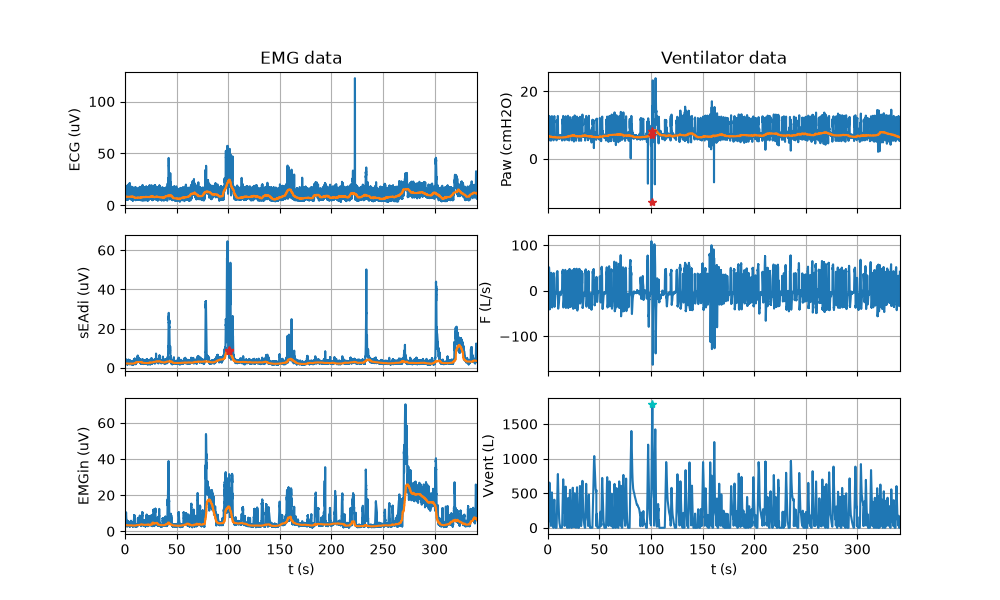

In [72]:
# Plot the identified Pocc peaks in p_vent and sEAdi
fig, axis = plt.subplots(nrows=3, ncols=2, figsize=(10, 6), sharex=True)
axes_emg = axis[:, 0]
colors = ["tab:cyan", "tab:orange", "tab:red"]
emg_timeseries.plot_full(axes=axes_emg, signal_type="env")
emg_di.plot_markers(peak_set_name="Pocc", axes=axes_emg[1])
# Which equals:
# emg_di.plot_markers(
#     peak_set_name='Pocc',
#     axes=axes_emg[1],
#     valid_only=False,
#     colors=['tab:red', 'tab:red', 'tab:red'],
#     markers=['*', '*', '*'],
# )
# Where:
# peak_set_name:    Peakset to plot the markers from
# axes:             Axes object to plot in
# valid_only:       Plot only valid peaks
# colors:           List of colours for the peak, start and end marker
# markers:          List of markers for the peak, start and end marker


axes_emg[1].set_ylabel("sEAdi (uV)")
axes_emg[0].set_title("EMG data")
axes_emg[-1].set_xlabel("t (s)")

axes_vent = axis[:, 1]
vent_timeseries.plot_full(axes=axes_vent)
p_vent.plot_markers(peak_set_name="Pocc", axes=axes_vent[0])
v_vent.plot_markers(peak_set_name="Pocc", axes=axes_vent[2], colors="c")

axes_vent[0].set_title("Ventilator data")
axes_vent[-1].set_xlabel("t (s)")
axes_vent[-1].set_xlim(t_emg_range)

# axis[-1, 0].axis("off")

In [73]:
vent_timeseries.find_occluded_breaths(vent_timeseries.p_vent_idx, start_idx=start_t * vent_timeseries.fs)
vent_timeseries[vent_timeseries.p_vent_idx].peaks["Pocc"].detect_on_offset(baseline=vent_timeseries[vent_timeseries.p_vent_idx].y_baseline)

c:\Users\ManinettiC\Documents\ReSurfEMG\resurfemg\data_connector\data_classes.py:137: FutureWarning:  The attribute y_baseline is deprecated to allow for more, and custom,
signal types. Use "TimeSeries"[baseline] instead.
  warnings.warn(


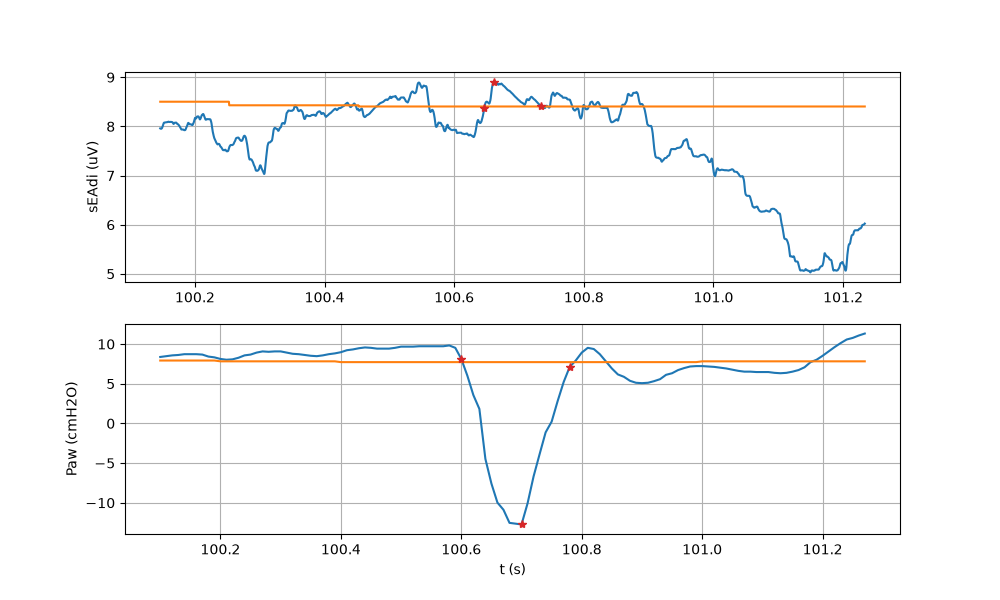

In [ ]:
# Plot the individual peaks
n_peaks = len(emg_di.peaks["Pocc"].peak_df["start_idx"].to_numpy())
if n_peaks:
    fig, axis = plt.subplots(nrows=2, ncols=n_peaks, figsize=(10, 6), sharey="row")

    axes_emg = axis[0, :] if n_peaks > 1 else np.array([axis[0]])
    colors = ["tab:cyan", "tab:orange", "tab:red"]
    emg_di.plot_peaks(axes=axes_emg, peak_set_name="Pocc")
    # Which equals:
    # emg_di.plot_peaks(
    #     peak_set_name='Pocc',
    #     axes=axes_emg,
    #     signal_type=emg_di.peaks['Pocc'].signal,    # == 'env'
    #     margin_s=emg_di.fs // 2,
    #     valid_only=False,
    #     colors=['tab:blue', 'tab:orange'],
    #     baseline_bool=True
    # )
    # Where:
    # peak_set_name:    Peakset to plot the markers from
    # axes:             Axes object to plot in
    # signal_type:      Plot the envelope data, from which the peaks are determined
    # margin_s:         Plot margin_s samples before start_idx and after end_idx
    # valid_only:       Plot only valid peaks
    # colors:           List of colours for the peak [0] and baseline [1]
    # baseline_bool:    Plot the baseline

    emg_di.plot_markers(axes=axes_emg, peak_set_name="Pocc")
    axes_emg[0].set_ylabel("sEAdi (uV)")

    axes_vent = axis[1, :] if n_peaks > 1 else np.array([axis[1]])
    p_vent.plot_peaks(axes=axes_vent, peak_set_name="Pocc")
    p_vent.plot_markers(axes=axes_vent, peak_set_name="Pocc")

    for axis in axes_vent:
        axis.set_xlabel("t (s)")

# 5. Calculate features: ETP and PTP

In [75]:
# Calculate PTPocc
importlib.reload(resurfemg.data_connector.data_classes)
p_vent.calculate_time_products(peak_set_name="Pocc", aub_reference_signal=p_vent.y_baseline, parameter_name="PTPocc")
# Which equals:
# p_vent.calculate_time_products(
#     peak_set_name='Pocc',
#     include_aub=True,
#     aub_window_s=5 * p_vent.fs,
#     aub_reference_signal=p_vent.y_baseline,
#     parameter_name='PTPocc')
# )
# Where:
# peak_set_name:        Peakset to calculate the timeproduct over
# include_aub:          Include the area under the baseline in the time product
# aub_window_s:         Window length in samples in which the local extreme is sought.
# aub_reference_signal: Optional reference signal to find the local extreme
#                       in, else the signal underlying the peakset is taken.
# parameter_name:       Name of the parameter in peakset.peak_df

# --> Parameter data is stored in:
# p_vent.peaks['Pocc'].peak_df[parameter_name]

print(p_vent.peaks["Pocc"].peak_df)

   peak_idx  start_idx  end_idx  valid       AUB  aub_y_ref    PTPocc
0     10070      10060    10078   True  0.145566     8.5306  2.188571


c:\Users\ManinettiC\Documents\ReSurfEMG\resurfemg\data_connector\data_classes.py:137: FutureWarning:  The attribute y_baseline is deprecated to allow for more, and custom,
signal types. Use "TimeSeries"[baseline] instead.
  warnings.warn(


In [76]:
# Calculate ETPdi
emg_di.calculate_time_products(peak_set_name="Pocc", parameter_name="ETPdi")

print(emg_di.peaks["Pocc"].peak_df)

   peak_idx  start_idx  end_idx  valid       AUB  aub_y_ref     ETPdi
0    206154     206124   206303   True  0.373248   4.135019  0.393031


# 6. Test Pocc and sEMG quality of the peaks

In [77]:
# Test Pocc quality
parameter_names = {"time_product": "PTPocc"}
p_vent.test_pocc_quality(peak_set_name="Pocc", parameter_names=parameter_names, verbose=True)
# Which equals:
# p_vent.test_pocc_quality(
#     peak_set_name='Pocc',
#     cutoff={
#         'consecutive_poccs': 0,
#         'dP_up_10': 0.0,
#         'dP_up_90': 2.0,
#         'dP_up_90_norm': 0.8,
#     },
#     skip_tests=[],
#     parameter_names={
#         'time_product': 'PTPocc'
#     },
#     verbose=True
# )
# Where:
# peak_set_name:        Peakset to test
# cutoff:               The cut-off values for the tests
# skip_tests:           List of tests to skip. Any of: 'consecutive_poccs',
#                       'pocc_upslope'
# parameter_names:      Dictionary of renamed parameters. Required parameters
#                       are 'ventilator_breaths', and 'time_product', and need
#                       to be specified if renamed.
# verbose:              Print the output of the tests

# --> Peak quality data is stored in:
# p_vent.peaks['Pocc'].quality_values_df and
# p_vent.peaks['Pocc'].quality_outcomes_df

INFO:resurfemg.helper_functions.data_classes_quality_assessment:Test values:
   peak_idx  dP_up_10  dP_up_90  dP_up_90_norm
0     10070   1.98052   3.04074       2.055412
INFO:resurfemg.helper_functions.data_classes_quality_assessment:Test outcomes:
   baseline_detection  peak_idx  consecutive_poccs  pocc_upslope
0                True     10070               True         False


In [78]:
# The peak-validity is updated in the peak_df:
print(p_vent.peaks["Pocc"].peak_df)

   peak_idx  start_idx  end_idx  valid       AUB  aub_y_ref    PTPocc
0     10070      10060    10078  False  0.145566     8.5306  2.188571


In [79]:
# Test EMG quality
parameter_names = {"time_product": "ETPdi"}
emg_di.test_emg_quality(peak_set_name="Pocc", parameter_names=parameter_names)
# Which equals:
# emg_di.test_emg_quality(
#     peak_set_name='Pocc',
#     cutoff={
#         'interpeak_distance': 1.1,
#         'snr': 1.4,
#         'aub': 40,
#         'curve_fit': 30,
#         'aub_window_s': 5*emg_di.fs
#     },
#     skip_tests=[],
#     parameter_names={
#         'time_product': 'ETPdi'
#     },
#     verbose=True
# )
# Where:
# peak_set_name:        Peakset to test
# cutoff:               The cut-off values for the tests
# skip_tests:           List of tests to skip. Any of: 'interpeak_dist',
#                       'snr', 'aub', 'curve_fit'
# parameter_names:      Dictionary of renamed parameters. Required parameters
#                       are ['interpeak_distance', 'snr', 'aub', 'curve_fit'],
#                       and need to be specified if renamed.
# verbose:              Print the output of the tests

# --> Peak quality data is stored in:
# emg_di.peaks['Pocc'].quality_values_df and
# emg_di.peaks['Pocc'].quality_outcomes_df

c:\.venvM3RESP\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\.venvM3RESP\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:resurfemg.helper_functions.data_classes_quality_assessment:Test values:
   peak_idx     snr        aub  aub_y_refs      bell
0    206154  1.0604  94.966761    4.135019  2.254376
INFO:resurfemg.helper_functions.data_classes_quality_assessment:Test outcomes:
   baseline_detection  peak_idx  interpeak_distance    snr    aub  bell  \
0                True    206154               False  False  False  True   

   relative_aub  relative_etp  
0          True          True  


In [80]:
# The peak-validity is updated in the peak_df:
print(emg_di.peaks["Pocc"].peak_df)

   peak_idx  start_idx  end_idx  valid       AUB  aub_y_ref     ETPdi  \
0    206154     206124   206303  False  0.373248   4.135019  0.393031   

   bell_y_min    bell_a      bell_b   bell_c  
0    4.135019  4.589324  100.676668  0.19874  


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

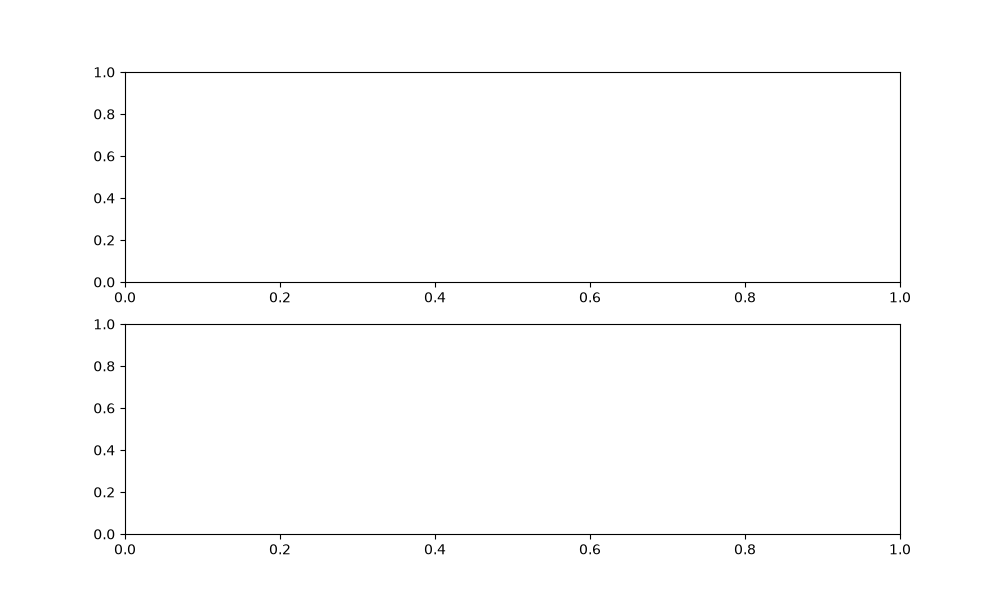

In [81]:
# Plot the individual peaks bell-fit
n_peaks = len(emg_di.peaks["Pocc"].peak_df["start_idx"].to_numpy())
fig, axis = plt.subplots(nrows=2, ncols=n_peaks, figsize=(10, 6), sharey="row")

axes_emg = axis[0, :]
colors = ["tab:cyan", "tab:orange", "tab:red"]
emg_di.plot_peaks(axes=axes_emg, peak_set_name="Pocc")
emg_di.plot_markers(axes=axes_emg, peak_set_name="Pocc")
emg_di.plot_curve_fits(axes=axes_emg, peak_set_name="Pocc")
# Which equals:
# emg_di.plot_curve_fits(
#     peak_set_name='Pocc',
#     axes=axes_emg,
#     valid_only=False,
#     colors='tab:green'
# )
# Where:
# peak_set_name:    Peakset to plot the bell fit from
# axes:             Axes object to plot in
# valid_only:       Plot only valid peaks
# colors:           Colour for the bell-fit
axes_emg[0].set_ylabel("sEAdi (uV)")

axes_vent = axis[1, :]
p_vent.plot_peaks(axes=axes_vent, peak_set_name="Pocc")
p_vent.plot_markers(axes=axes_vent, peak_set_name="Pocc")

for axis in axes_vent:
    axis.set_xlabel("t (s)")

/Users/chiaramaninetti/Documents/M3RESP/ReSurfEMG/resurfemg/data_connector/data_classes.py:1349: FutureWarning: The "signal_type" argument is deprecated. Use "signal_io"
instead: signal_io = (`input_name`,).
  warnings.warn(


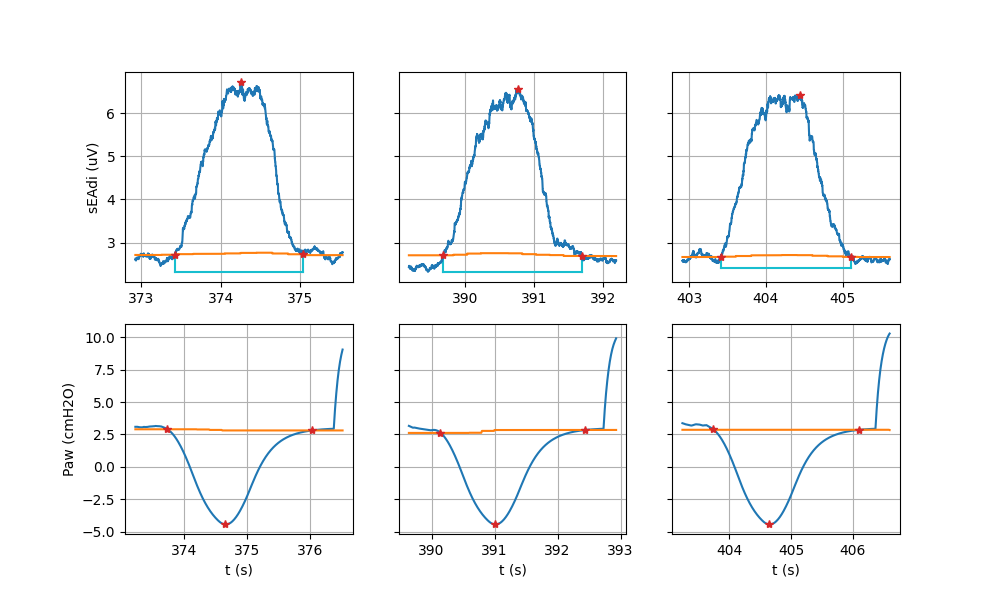

In [ ]:
# Plot the individual peaks bell-fit
n_peaks = len(emg_di.peaks["Pocc"].peak_df["start_idx"].to_numpy())
fig, axis = plt.subplots(nrows=2, ncols=n_peaks, figsize=(10, 6), sharey="row")

axes_emg = axis[0, :]
emg_di.plot_aub(axes=axes_emg, signal_type="env", peak_set_name="Pocc")
# Which equals:
# emg_di.plot_curve_fits(
#     peak_set_name='Pocc',
#     axes=axes_emg,
#     valid_only=False,
#     colors='tab:cyan'
# )
# Where:
# peak_set_name:    Peakset to plot the aub from
# axes:             Axes object to plot in
# signal_type:      Plot aub for this data, in this case the aub data
# valid_only:       Plot only valid peaks
# colors:           Colour for the aub
colors = ["tab:cyan", "tab:orange", "tab:red"]
emg_di.plot_peaks(axes=axes_emg, peak_set_name="Pocc")
emg_di.plot_markers(axes=axes_emg, peak_set_name="Pocc")
axes_emg[0].set_ylabel("sEAdi (uV)")

axes_vent = axis[1, :]
p_vent.plot_peaks(axes=axes_vent, peak_set_name="Pocc")
p_vent.plot_markers(axes=axes_vent, peak_set_name="Pocc")

for axis in axes_vent:
    axis.set_xlabel("t (s)")